In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

/home/hsm/python_ai/intro/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 2.29G/2.29G [02:22<00:00, 17.3MB/s]

Extracting files...


Path to dataset files: /home/hsm/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2


In [24]:
import numpy as np # forlinear algebra
import matplotlib.pyplot as plt #for plotting things
import os
from PIL import Image # for reading images

# Keras Libraries <- CNN
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, Model, Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D, Flatten, Dense, Input, BatchNormalization, Concatenate, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
#from sklearn.metrics import classification_report, confusion_matrix # <- define evaluation metrics

In [25]:
mainDIR = os.listdir('./chest_xray')
print(mainDIR)
train_folder= './chest_xray/train/'
val_folder = './chest_xray/val/'
test_folder = './chest_xray/test/'
# train 
os.listdir(train_folder)
train_n = train_folder+'NORMAL/'
train_p = train_folder+'PNEUMONIA/'
#Normal pic 
print(len(os.listdir(train_n)))
rand_norm= np.random.randint(0,len(os.listdir(train_n)))
norm_pic = os.listdir(train_n)[rand_norm]
print('normal picture title: ',norm_pic)
norm_pic_address = train_n+norm_pic
#Pneumonia
rand_p = np.random.randint(0,len(os.listdir(train_p)))
sic_pic = os.listdir(train_p)[rand_norm]
sic_address = train_p+sic_pic
print('pneumonia picture title:', sic_pic)

['val', '.DS_Store', 'test', 'train']
1342
normal picture title:  NORMAL2-IM-0870-0001.jpeg
pneumonia picture title: person1129_virus_1857.jpeg


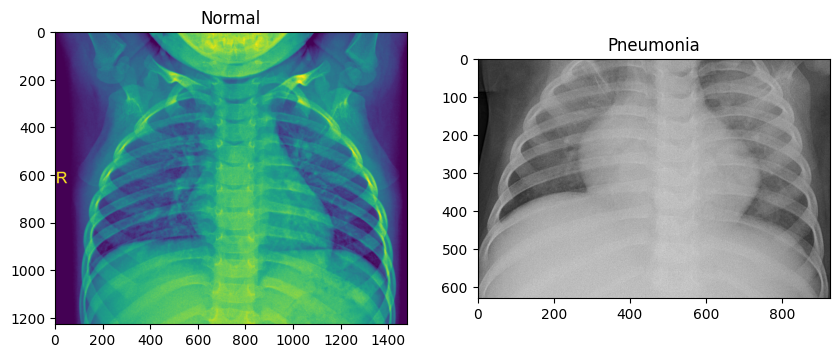

In [26]:
# Load the images
norm_load = Image.open(norm_pic_address)
sic_load = Image.open(sic_address)

#Let's plt these images
f = plt.figure(figsize= (10,6))
a1 = f.add_subplot(1,2,1)
img_plot = plt.imshow(norm_load)
a1.set_title('Normal')

a2 = f.add_subplot(1, 2, 2)
img_plot = plt.imshow(sic_load)
a2.set_title('Pneumonia')
plt.show()
# let's build the CNN model

# HW3

--------------------------------------------------------------------------------------------------------------------------------------

모델 세팅만 해주기
model_in = input(shape = (64,64,3))
이걸로 나중에 model_fin.summary() 해도 결과가 예쁘게 나올 수 있게 해주는 느낌

In [27]:
#cnn = Sequential()
#Convolution
model_in = Input(shape = (64, 64, 3))
model = Flatten()(model_in)
# Fully Connected Layers
model = Dense(activation = 'relu', units = 128) (model)
model = Dense(activation = 'sigmoid', units = 1)(model)
# Compile the Neural network
model_fin = Model(inputs=model_in, outputs=model)
model_fin.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

dataset preparation

In [28]:
num_of_test_samples = 600
batch_size = 32

# Fitting the CNN to the images
# The function ImageDataGenerator augments your image by iterating through image as your CNN is getting ready to process that image

train_datagen = ImageDataGenerator(rescale = 1./255, shear_range = 0.2,zoom_range = 0.2,horizontal_flip = True)

test_datagen = ImageDataGenerator(rescale = 1./255) #Image normalization.

training_set = train_datagen.flow_from_directory('./chest_xray/train',target_size = (64, 64),batch_size = 32, class_mode = 'binary')

Found 5216 images belonging to 2 classes.


dataset preparation (cont'd)

In [29]:
validation_generator = test_datagen.flow_from_directory('./chest_xray/val/',target_size=(64, 64),batch_size=32,class_mode='binary')

test_set = test_datagen.flow_from_directory ('./chest_xray/test',target_size=(64, 64),batch_size=32,class_mode='binary')
model_fin.summary()

Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,573,121 (6.00 MB)

 Trainable params: 1,573,121 (6.00 MB)

 Non-trainable params: 0 (0.00 B)

# HW4

cnn_model = model_fin.fit~~ 해줘야 여기에 history에 사용할 수 있게 데이터들이 저장됨.

In [ ]:
cnn_model = model_fin.fit(training_set,steps_per_epoch = 163,epochs = 10,validation_data = validation_generator,validation_steps = 624)

test_accu = model_fin.evaluate(test_set,steps=624)

model_fin.save('medical_ann.h5')
print('The testing accuracy is :',test_accu[1]*100, '%')
Y_pred = model_fin.predict(test_set, 100)
y_pred = np.argmax(Y_pred, axis=1)
max(y_pred)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 17s 104ms/step - accuracy: 0.6638 - loss: 1.1431 - val_accuracy: 0.5000 - val_loss: 0.7109
Epoch 2/10


/home/hsm/python_ai/intro/.venv/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/home/hsm/python_ai/intro/.venv/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


163/163 ━━━━━━━━━━━━━━━━━━━━ 17s 104ms/step - accuracy: 0.7509 - loss: 0.4616 - val_accuracy: 0.6250 - val_loss: 0.7360
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 17s 103ms/step - accuracy: 0.8524 - loss: 0.3648 - val_accuracy: 0.7500 - val_loss: 0.5710
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 17s 101ms/step - accuracy: 0.8735 - loss: 0.3441 - val_accuracy: 0.8750 - val_loss: 0.5646
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - accuracy: 0.8818 - loss: 0.3173 - val_accuracy: 0.6250 - val_loss: 0.6670
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 17s 102ms/step - accuracy: 0.8813 - loss: 0.3164 - val_accuracy: 0.8125 - val_loss: 0.5441
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 17s 103ms/step - accuracy: 0.8920 - loss: 0.2972 - val_accuracy: 0.8750 - val_loss: 0.5187
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 17s 102ms/step - accuracy: 0.8919 - loss: 0.2940 - val_accuracy: 0.7500 - val_loss: 0.6015
Epoch 9/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 17s 102ms/step - accuracy: 0.8890 - loss: 0.2897 - val

The testing accuracy is : 84.61538553237915 %
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step


np.int64(0)

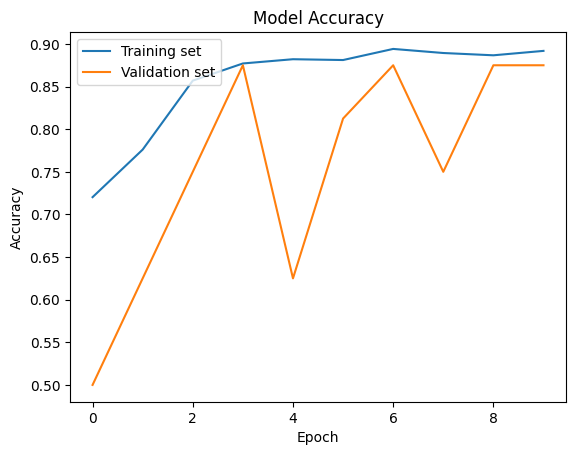

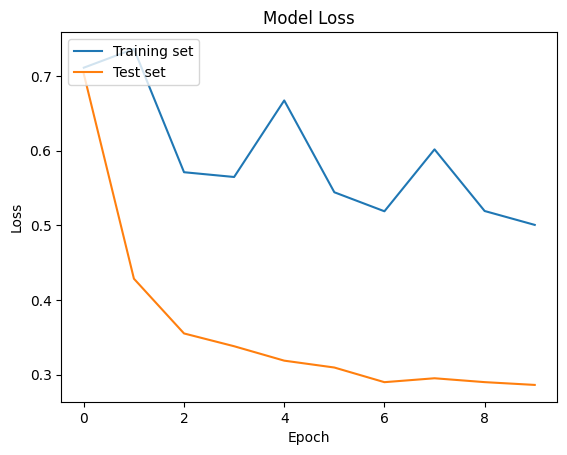

<Figure size 640x480 with 0 Axes>

In [22]:
# Accuracy 
plt.plot(cnn_model.history['accuracy'])
plt.plot(cnn_model.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training set', 'Validation set'], loc='upper left')
plt.savefig('train_accuracy.png')
plt.show(block=False)
plt.clf()

# Loss 
plt.plot(cnn_model.history['val_loss'])
plt.plot(cnn_model.history['loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training set', 'Test set'], loc='upper left')
plt.savefig('train_loss.png')
plt.show(block=False)
plt.clf()

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 17s 104ms/step - accuracy: 0.7408 - loss: 0.5391 - val_accuracy: 0.6250 - val_loss: 1.3176
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 17s 105ms/step - accuracy: 0.8462 - loss: 0.3324 - val_accuracy: 0.6250 - val_loss: 0.6120
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 17s 103ms/step - accuracy: 0.8712 - loss: 0.3138 - val_accuracy: 0.8125 - val_loss: 0.4596
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 17s 102ms/step - accuracy: 0.8842 - loss: 0.2718 - val_accuracy: 0.8750 - val_loss: 0.4506
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 17s 102ms/step - accuracy: 0.8853 - loss: 0.2776 - val_accuracy: 0.7500 - val_loss: 0.4608
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 17s 104ms/step - accuracy: 0.8857 - loss: 0.2670 - val_accuracy: 0.6250 - val_loss: 0.7641
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - accuracy: 0.8872 - loss: 0.2648 - val_accuracy: 0.6250 - val_loss: 0.6757
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - accuracy: 0.8826 - loss: 0

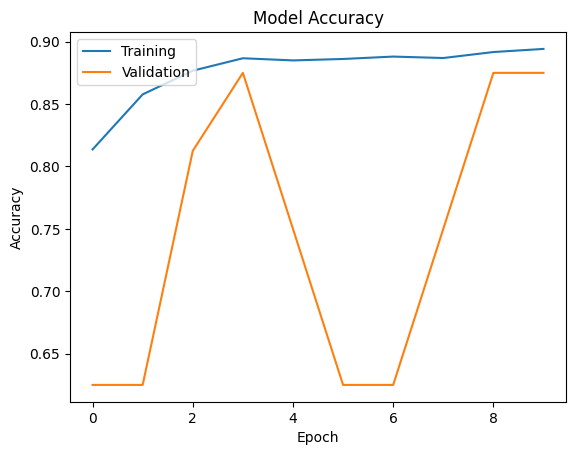

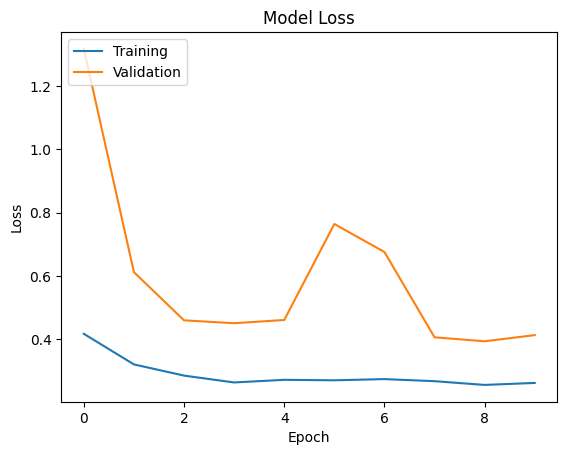

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np

# ANN 모델 구조
model_ann = Sequential([
    Flatten(input_shape=(64, 64, 3)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_ann.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# 학습
steps_per_epoch = training_set.samples // training_set.batch_size
validation_steps = validation_generator.samples // validation_generator.batch_size

maf = model_ann.fit(  # ← 결과를 maf에 저장
    training_set,
    steps_per_epoch=steps_per_epoch,
    epochs=10,
    validation_data=validation_generator,
    validation_steps=validation_steps
)

# 평가
test_accu_maf = model_ann.evaluate(test_set, steps=624)
print('The testing accuracy is:', test_accu_maf[1] * 100, '%')

# 예측
Y_pred = model_ann.predict(test_set, steps=100)
y_pred = (Y_pred > 0.5).astype(int)

# 정확도 그래프
plt.plot(maf.history['accuracy'])
plt.plot(maf.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.savefig('train_accuracy.png')
plt.show()

# 손실 그래프
plt.plot(maf.history['loss'])
plt.plot(maf.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.savefig('train_loss.png')
plt.show()

In [38]:
model_ann.save('medical_ann_2.h5')

#cnn = Sequential()
#Convolution
model_in = Input(shape = (64, 64, 3))
model = Flatten()(model_in)
# Fully Connected Layers
model = Dense(activation = 'relu', units = 128) (model)
model = Dense(activation = 'sigmoid', units = 1)(model)
# Compile the Neural network
model_fin = Model(inputs=model_in, outputs=model)
model_fin.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

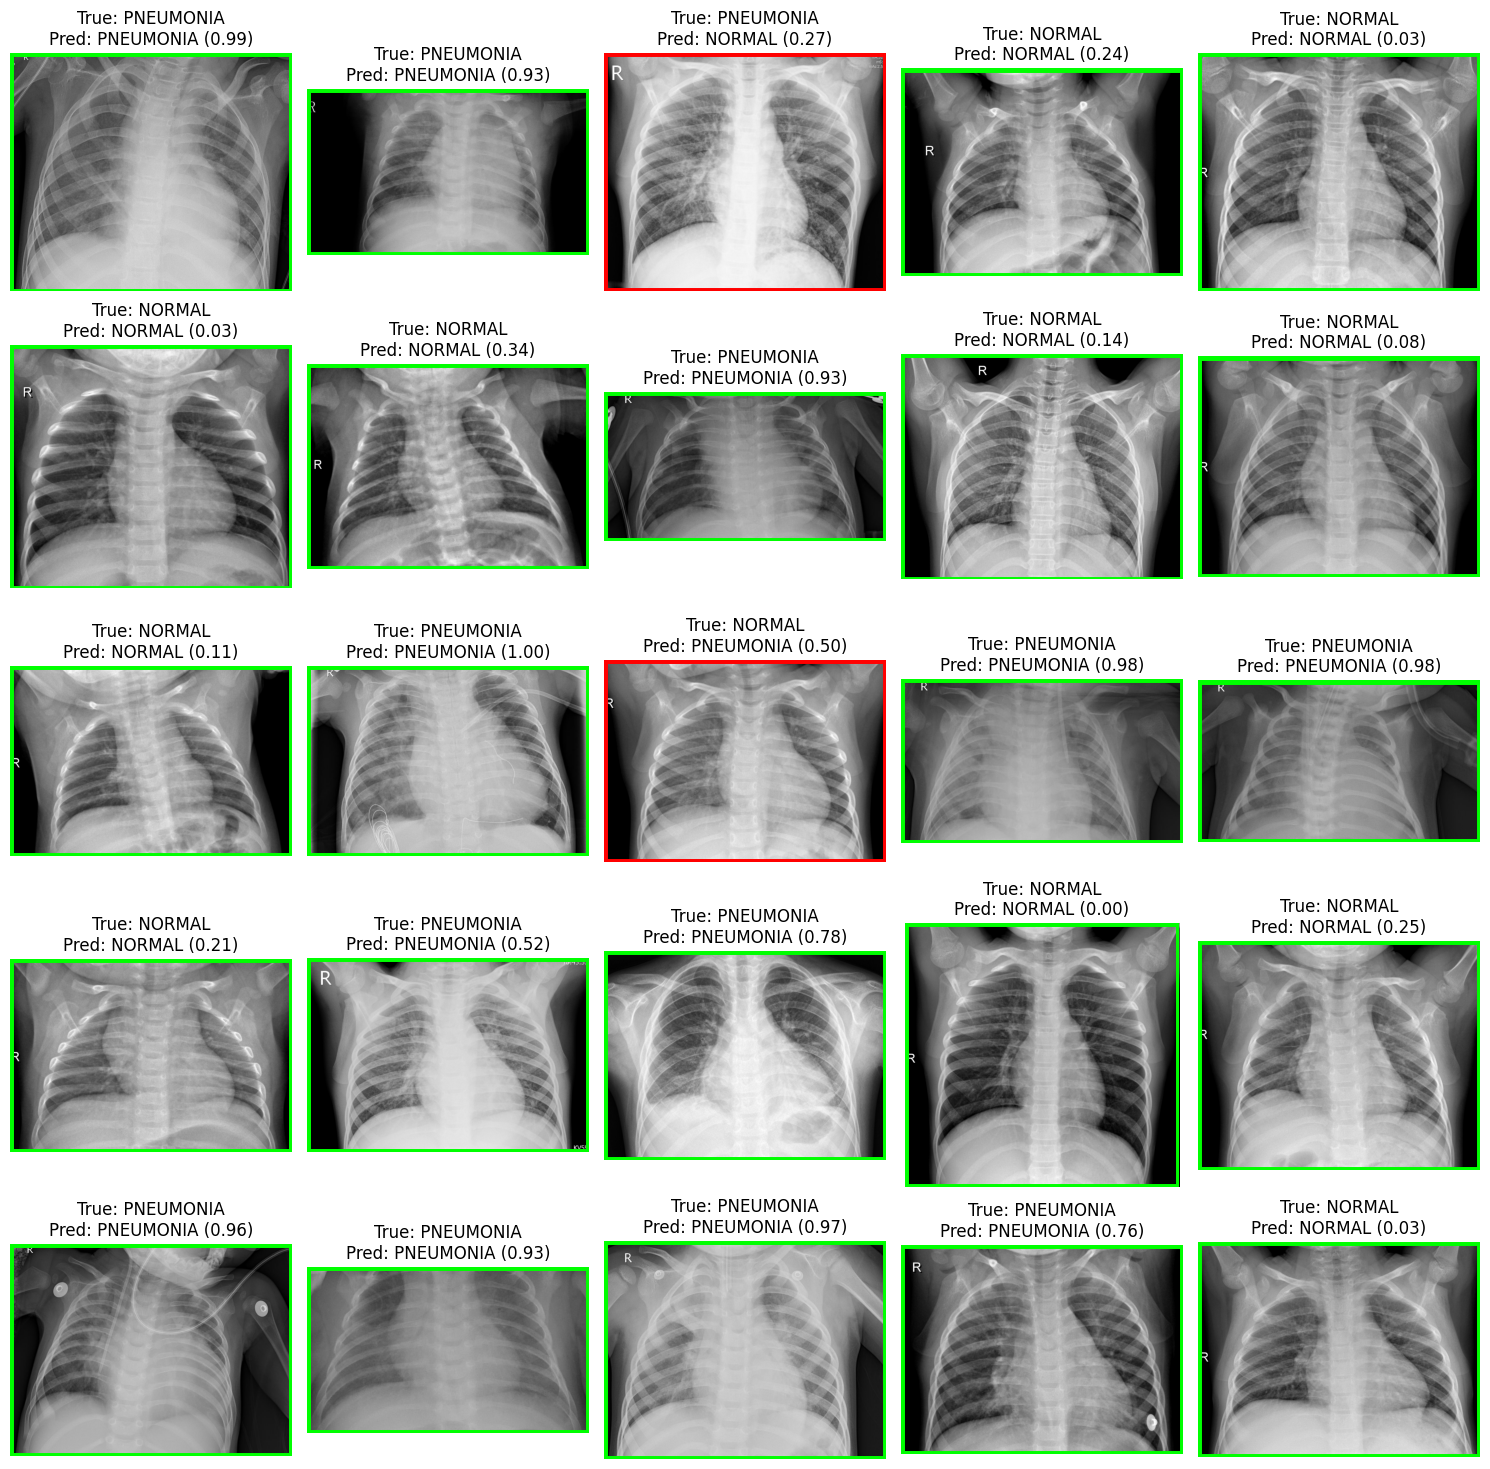

In [43]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# 1. 데이터 경로 설정
base_dir = './chest_xray/train/'
normal_dir = os.path.join(base_dir, 'NORMAL')
pneu_dir = os.path.join(base_dir, 'PNEUMONIA')

# 2. 클래스별 무작위 샘플 선택 (총 25개)
num_total = 25
num_per_class = num_total // 2

normal_files = np.random.choice(os.listdir(normal_dir), size=num_per_class, replace=False)
pneu_files = np.random.choice(os.listdir(pneu_dir), size=num_total - num_per_class, replace=False)

img_info = [(os.path.join(normal_dir, f), 0) for f in normal_files] + \
           [(os.path.join(pneu_dir, f), 1) for f in pneu_files]

np.random.shuffle(img_info)  # 랜덤 섞기

# 3. 모델 불러오기
model = load_model('medical_ann_2.h5')

# 4. 전처리 함수 (모델 입력용 64x64 RGB)
def preprocess(img_path):
    img = image.load_img(img_path, target_size=(64, 64))
    img_arr = image.img_to_array(img) / 255.0
    return np.expand_dims(img_arr, axis=0)

# 5. 클래스 이름 매핑
label_name = {0: "NORMAL", 1: "PNEUMONIA"}

# 6. 시각화
plt.figure(figsize=(15, 15))

for i, (img_path, true_label) in enumerate(img_info):
    # 예측
    input_tensor = preprocess(img_path)
    pred_prob = model.predict(input_tensor, verbose=0)[0][0]
    pred_class_num = int(pred_prob > 0.5)
    pred_class_str = label_name[pred_class_num]

    # 원본 이미지 로드
    img_show = image.load_img(img_path)

    # 서브플롯 생성
    ax = plt.subplot(5, 5, i + 1)
    ax.imshow(img_show)
    ax.axis('off')

    # 제목 설정
    ax.set_title(f"True: {label_name[true_label]}\nPred: {pred_class_str} ({pred_prob:.2f})")

    # 테두리 색상 결정
    if pred_class_num == true_label:
        edge_color = 'lime'  # 초록색
    else:
        edge_color = 'red'   # 빨강색

    # 이미지 크기 얻기
    w, h = img_show.size

    # 테두리 사각형 추가
    rect = Rectangle((0, 0), w, h, linewidth=5, edgecolor=edge_color, facecolor='none')
    ax.add_patch(rect)

plt.tight_layout()
plt.show()
